# Problem2


TASK-0: DATASET

In [1]:
with open('TrainingNames.txt','r') as f:
    names = f.read().splitlines()

In [2]:
len(names)

1001

In [3]:
# get all unique characters and creating the vocab
chars = sorted(list(set("".join(names))))
chars = ["<PAD>", "<SOS>", "<EOS>"] + chars
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i:ch for i,ch in enumerate(chars)}

vocab_size = len(chars)

print("Vocab size:", vocab_size)
print(chars)

Vocab size: 24
['<PAD>', '<SOS>', '<EOS>', 'a', 'c', 'd', 'e', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y']


In [4]:
#encoding the names
def encode_name(name):
    name = name.lower()
    encoded = [char_to_idx["<SOS>"]]
    
    for ch in name:
        encoded.append(char_to_idx[ch])
        
    encoded.append(char_to_idx["<EOS>"])
    
    return encoded

In [5]:
encode_name('Pragati'), encode_name('Ravi')

([1, 16, 17, 3, 7, 3, 19, 9, 2], [1, 17, 3, 21, 9, 2])

In [6]:
max_length = 0
for name in names:
    if max_length<len(name):
        max_length = len(name)
max_length = max_length+2 # adding extra two for <SOS> and <EOS>

# TO make the encodings equal length
def pad_sequence(seq):
    return seq + [char_to_idx["<PAD>"]] * (max_length - len(seq))

In [7]:
encoded_names = [encode_name(name) for name in names]
padded_names = [pad_sequence(seq) for seq in encoded_names]

In [8]:
pad_sequence(encode_name('Pragati')), pad_sequence(encode_name('Ravi'))

([1, 16, 17, 3, 7, 3, 19, 9, 2, 0, 0, 0, 0],
 [1, 17, 3, 21, 9, 2, 0, 0, 0, 0, 0, 0, 0])

TASK-1: MODEL IMPLEMENTATION

In [100]:
import torch
import torch.nn as nn
import torch.optim as optim
import random

In [101]:
# defining the RNN model
class CharRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super(CharRNN, self).__init__()
        
        self.hidden_size = hidden_size
        
        # input to hidden
        self.i2h = nn.Linear(vocab_size + hidden_size, hidden_size)
        
        # hidden to output
        self.h2o = nn.Linear(hidden_size, vocab_size)
        
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        combined = torch.cat((input, hidden), 1)
        
        hidden = self.i2h(combined)
        output = self.h2o(hidden)
        output = self.softmax(output)
        
        return output, hidden

    def init_hidden(self):
        return torch.zeros(1, self.hidden_size)

In [102]:
# One-hot encoding
def char_to_tensor(char):
    tensor = torch.zeros(1, vocab_size)
    tensor[0][char_to_idx[char]] = 1
    return tensor

In [103]:
#Converting the name to tensors
def name_to_tensors(name):
    input_tensor = []
    target_tensor = []
    
    for i in range(len(name)):
        input_tensor.append(char_to_tensor(name[i]))
        
        if i < len(name) - 1:
            target_tensor.append(char_to_idx[name[i+1]])
        else:
            target_tensor.append(char_to_idx["<EOS>"])
    
    return input_tensor, torch.tensor(target_tensor)

In [104]:
# initializing the model
hidden_size = 128
model = CharRNN(vocab_size, hidden_size)

criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

In [ ]:
# starting the training loop
def train_RNN(name):
    hidden = model.init_hidden()
    model.zero_grad()
    
    input_tensor, target_tensor = name_to_tensors(name)
    
    loss = 0
    
    for i in range(len(input_tensor)):
        output, hidden = model(input_tensor[i], hidden)
        loss += criterion(output, target_tensor[i].unsqueeze(0))
    
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 3)
    optimizer.step()
    
    loss = loss / len(input_tensor)
    return loss.item()

In [106]:
losses_RNN = []
epochs = 50
for epoch in range(epochs):
    total_loss = 0
    
    random.shuffle(names)

    for name in names:
        total_loss += train_RNN(name)
    losses_RNN.append(total_loss/len(names))
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(names)}")

Epoch 1, Loss: 1.809440905635769
Epoch 2, Loss: 1.4321131425482647
Epoch 3, Loss: 1.3383682925443907
Epoch 4, Loss: 1.3044990704103665
Epoch 5, Loss: 1.2643766338740672
Epoch 6, Loss: 1.2375533094743154
Epoch 7, Loss: 1.209531436418439
Epoch 8, Loss: 1.1893214550944833
Epoch 9, Loss: 1.173914397021869
Epoch 10, Loss: 1.1510775509503457
Epoch 11, Loss: 1.1373671263486118
Epoch 12, Loss: 1.123479898457046
Epoch 13, Loss: 1.0972256584243698
Epoch 14, Loss: 1.1022444541875895
Epoch 15, Loss: 1.0800484509824158
Epoch 16, Loss: 1.0791598617971003
Epoch 17, Loss: 1.0727333222756852
Epoch 18, Loss: 1.0578440565478195
Epoch 19, Loss: 1.0525229551366992
Epoch 20, Loss: 1.0510421228128952
Epoch 21, Loss: 1.050248212941162
Epoch 22, Loss: 1.0616486992065486
Epoch 23, Loss: 1.0332012523215015
Epoch 24, Loss: 1.0352883945543925
Epoch 25, Loss: 1.0343651689670899
Epoch 26, Loss: 1.034733618115569
Epoch 27, Loss: 1.0116905479075073
Epoch 28, Loss: 1.035995755839598
Epoch 29, Loss: 1.022274039782487
Ep

Text(0.5, 1.0, 'Losses RNN')

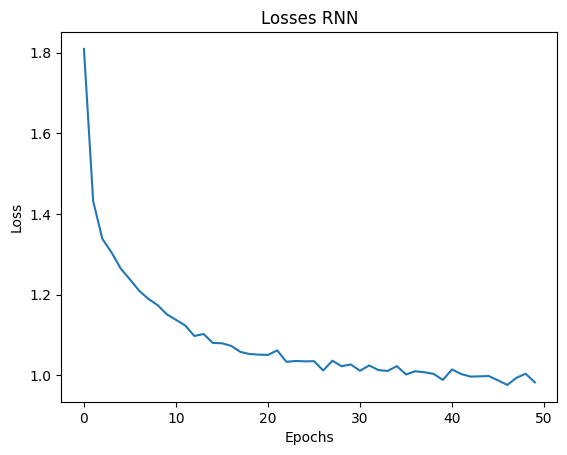

In [107]:
import matplotlib.pyplot as plt
plt.plot(range(epochs),losses_RNN)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Losses RNN')

In [119]:
import random

def generate_name_RNN( max_length=10):
    with torch.no_grad():
        hidden = model.init_hidden()
        
        start_letters = list(set(name[0] for name in names))

        start_char = random.choice(start_letters)
        
        # avoid special tokens
        while start_char in ["<PAD>", "<SOS>", "<EOS>"]:
            start_char = random.choice(list(char_to_idx.keys()))
        
        input = char_to_tensor(start_char)
        name = start_char
        
        for _ in range(max_length):
            output, hidden = model(input, hidden)
            
            probs = torch.exp(output)
            temperature = 0.7
            output = output / temperature
            probs = torch.exp(output)
            char_idx = torch.multinomial(probs, 1).item()
            
            char = idx_to_char[char_idx]
            
            if char == "<EOS>":
                break
                
            name += char
            input = char_to_tensor(char)
        
        if len(name) < 3:
            pass
        else:
            return name

In [120]:
for _ in range(10):
    print(generate_name_RNN())

deepaki
manoj
yashan
ravi
yashi
suniti
seema
dineshi
nohethya
ajayan


LSTM model

In [121]:
class CharBLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super(CharBLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        
        self.lstm = nn.LSTM(
            hidden_size,
            hidden_size,
            bidirectional=True
        )
        
        # because bidirectional → hidden*2
        self.fc = nn.Linear(hidden_size * 2, vocab_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        embedded = self.embedding(input.argmax(dim=1)).unsqueeze(0)
        
        output, hidden = self.lstm(embedded, hidden)
        
        output = self.fc(output.squeeze(0))
        output = self.softmax(output)
        
        return output, hidden

    def init_hidden(self):
        return (
            torch.zeros(2, 1, self.hidden_size),  # 2 for bidirectional
            torch.zeros(2, 1, self.hidden_size)
        )

In [122]:
hidden_size = 256
model_BLSTM = CharBLSTM(vocab_size, hidden_size)

criterion = nn.NLLLoss()
optimizer_LSTM = torch.optim.Adam(model_BLSTM.parameters(), lr=0.003)

In [ ]:
def train_LSTM(name):
    hidden = model_BLSTM.init_hidden()
    model_BLSTM.zero_grad()
    
    input_tensor, target_tensor = name_to_tensors(name)
    
    loss = 0
    
    for i in range(len(input_tensor)):
        output, hidden = model_BLSTM(input_tensor[i], hidden)
        loss += criterion(output, target_tensor[i].unsqueeze(0))
    
    loss = loss / len(input_tensor)
    
    loss.backward()
    
    torch.nn.utils.clip_grad_norm_(model_BLSTM.parameters(), 5)
    optimizer_LSTM.step()
    
    return loss.item()

In [125]:
import random

losses_BLSTM = []

epochs = 50

for epoch in range(epochs):
    total_loss = 0
    
    random.shuffle(names)
    
    for name in names:
        total_loss += train_LSTM(name)
    losses_BLSTM.append(total_loss/len(names))
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(names)}")

Epoch 1, Loss: 0.9902089847313179
Epoch 2, Loss: 0.8044116939683179
Epoch 3, Loss: 0.7553002242665072
Epoch 4, Loss: 0.7402525977952616
Epoch 5, Loss: 0.725539225701626
Epoch 6, Loss: 0.7204967328346336
Epoch 7, Loss: 0.7260417223095775
Epoch 8, Loss: 0.7222973625068659
Epoch 9, Loss: 0.7036850859488283
Epoch 10, Loss: 0.6941329885225791
Epoch 11, Loss: 0.6996708578103549
Epoch 12, Loss: 0.6879042596384124
Epoch 13, Loss: 0.6965047535035279
Epoch 14, Loss: 0.6818978500577596
Epoch 15, Loss: 0.6861576721087084
Epoch 16, Loss: 0.6789561332939388
Epoch 17, Loss: 0.6733871149150403
Epoch 18, Loss: 0.681376936775702
Epoch 19, Loss: 0.6813644571201903
Epoch 20, Loss: 0.6748568669899361
Epoch 21, Loss: 0.6645252899704994
Epoch 22, Loss: 0.6675191788332208
Epoch 23, Loss: 0.6735965623394712
Epoch 24, Loss: 0.6793729783846186
Epoch 25, Loss: 0.6681304526153382
Epoch 26, Loss: 0.6766824629101958
Epoch 27, Loss: 0.666321830889145
Epoch 28, Loss: 0.6644545677680891
Epoch 29, Loss: 0.66149611178632

Text(0.5, 1.0, 'Losses BLSTM')

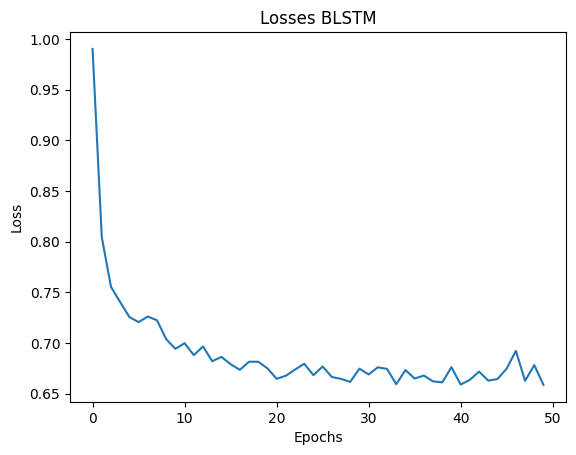

In [126]:
import matplotlib.pyplot as plt
plt.plot(range(epochs),losses_BLSTM)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Losses BLSTM')

In [127]:
def generate_name_BLSTM(max_length=10):
    with torch.no_grad():
        hidden = model_BLSTM.init_hidden()
        
        import random
        start_char = random.choice(list(char_to_idx.keys()))
        while start_char in ["<PAD>", "<SOS>", "<EOS>"]:
            start_char = random.choice(list(char_to_idx.keys()))
        
        input = char_to_tensor(start_char)
        name = start_char
        
        for _ in range(max_length):
            output, hidden = model_BLSTM(input, hidden)

            temperature = 0.7
            output = output / temperature
            probs = torch.exp(output)

            char_idx = torch.multinomial(probs, 1).item()
            char = idx_to_char[char_idx]

            if char == "<EOS>" and len(name) >= 3:
                break

            name += char
            input = char_to_tensor(char)

        return name

In [130]:
for _ in range(10):
    print(generate_name_BLSTM())

yashi
tanvi
wulya
pankaja
rajesh
preetia
ishai
eema
yash
ajayan


Attention RNN Model

In [146]:
class CharRNNAttention(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super(CharRNNAttention, self).__init__()
        self.hidden_size = hidden_size

        # RNN-style recurrence
        self.i2h = nn.Linear(vocab_size + hidden_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, vocab_size)

        # simple attention over previous hidden states
        self.attn = nn.Linear(hidden_size * 2, hidden_size)

        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden, prev_hidden_states):
        """
        input:  [1, vocab_size]
        hidden: [1, hidden_size]
        prev_hidden_states: list of tensors, each [1, hidden_size]
        """
        combined = torch.cat((input, hidden), dim=1)
        hidden = torch.tanh(self.i2h(combined))

        if len(prev_hidden_states) > 0:
            # [T, hidden_size]
            prev = torch.cat(prev_hidden_states, dim=0)

            # scores: [T]
            scores = torch.matmul(prev, hidden.squeeze(0).unsqueeze(1)).squeeze(1)

            # weights: [T]
            attn_weights = torch.softmax(scores, dim=0)

            # context: [hidden_size]
            context = torch.sum(attn_weights.unsqueeze(1) * prev, dim=0)

            # combine current hidden + context
            hidden = torch.tanh(
                self.attn(torch.cat((hidden, context.unsqueeze(0)), dim=1))
            )

        output = self.h2o(hidden)
        output = self.softmax(output)
        return output, hidden

    def init_hidden(self):
        return torch.zeros(1, self.hidden_size)

In [147]:
hidden_size = 256
model_ATT = CharRNNAttention(vocab_size, hidden_size)
optimizer_ATT = torch.optim.Adam(model_ATT.parameters(), lr=0.001)
criterion = nn.NLLLoss()

In [148]:
def train_ATT(name):
    hidden = model_ATT.init_hidden()
    prev_hidden_states = []

    model_ATT.zero_grad()

    input_tensor, target_tensor = name_to_tensors(name)
    loss = 0

    for i in range(len(input_tensor)):
        output, hidden = model_ATT(input_tensor[i], hidden, prev_hidden_states)
        prev_hidden_states.append(hidden)

        loss += criterion(output, target_tensor[i].unsqueeze(0))

    loss = loss / len(input_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_ATT.parameters(), 3)
    optimizer_ATT.step()

    return loss.item()

In [149]:
losses_RNNAT = []
epochs = 80

for epoch in range(epochs):
    total_loss = 0
    random.shuffle(names)

    for name in names:
        total_loss += train_ATT(name)

    avg_loss = total_loss / len(names)
    losses_RNNAT.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss}")

Epoch 1, Loss: 2.0924385881328678
Epoch 2, Loss: 1.617795935758463
Epoch 3, Loss: 1.3255069743503223
Epoch 4, Loss: 1.147648961066485
Epoch 5, Loss: 1.0343797079005561
Epoch 6, Loss: 0.9470517408478629
Epoch 7, Loss: 0.8941907168446959
Epoch 8, Loss: 0.8430329356249515
Epoch 9, Loss: 0.83089075893253
Epoch 10, Loss: 0.7998803214697571
Epoch 11, Loss: 0.7673716122632498
Epoch 12, Loss: 0.7461987103109474
Epoch 13, Loss: 0.7193747247968402
Epoch 14, Loss: 0.7002957031190336
Epoch 15, Loss: 0.6939120560616523
Epoch 16, Loss: 0.7006192273282623
Epoch 17, Loss: 0.7163024836933458
Epoch 18, Loss: 0.7015101702718229
Epoch 19, Loss: 0.6956919640243113
Epoch 20, Loss: 0.7045726402849704
Epoch 21, Loss: 0.7072961903237677
Epoch 22, Loss: 0.6860015109017655
Epoch 23, Loss: 0.6815251908846549
Epoch 24, Loss: 0.7004643004912359
Epoch 25, Loss: 0.6898872127214988
Epoch 26, Loss: 0.6723234851981377
Epoch 27, Loss: 0.6996639557964318
Epoch 28, Loss: 0.6744898228155268
Epoch 29, Loss: 0.672432505673580

Text(0.5, 1.0, 'Losses RNNAT')

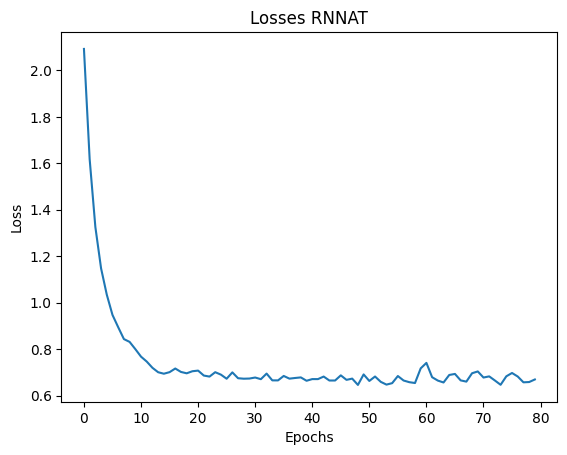

In [150]:
import matplotlib.pyplot as plt
plt.plot(range(epochs),losses_RNNAT)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Losses RNNAT')

In [151]:
def generate_name_ATT(max_length=10):
    with torch.no_grad():
        hidden = model_ATT.init_hidden()
        prev_hidden_states = []

        start_char = random.choice(list(char_to_idx.keys()))
        while start_char in ["<PAD>", "<SOS>", "<EOS>"]:
            start_char = random.choice(list(char_to_idx.keys()))

        input = char_to_tensor(start_char)
        name = start_char

        for _ in range(max_length):
            output, hidden = model_ATT(input, hidden, prev_hidden_states)
            prev_hidden_states.append(hidden)

            temperature = 0.45
            output = output / temperature
            probs = torch.exp(output)

            char_idx = torch.multinomial(probs, 1).item()
            char = idx_to_char[char_idx]

            if char == "<EOS>" and len(name) >= 3:
                break

            name += char
            input = char_to_tensor(char)

        return name

In [153]:
for _ in range(10):
    print(generate_name_ATT())

lanan
ishaa
poojai
wootia
sanjayan
varunan
varunya
uanan
nidhia
ounkshan


Out of the models BLSTM produced the best performance with most natural, best structure, clean endings. RNN produced realistic outputs with slight suffix distortion while attention RNN gave structured output with slight over-extension and vowel slight over-extension.

TASK-2: Quantitative Evaluation

Generate names

In [154]:
num_samples = 200

rnn_names = [generate_name_RNN() for _ in range(num_samples)]
blstm_names = [generate_name_BLSTM() for _ in range(num_samples)]
att_names = [generate_name_ATT() for _ in range(num_samples)]

Novelty Rate

In [155]:
def novelty_rate(generated, training):
    generated_set = set(generated)
    training_set = set(training)
    
    novel = generated_set - training_set
    return len(novel) / len(generated_set)

Diversity

In [156]:
def diversity(names):
    return len(set(names)) / len(names)

Compute metrics

In [157]:
print("RNN Novelty:", novelty_rate(rnn_names, names))
print("BLSTM Novelty:", novelty_rate(blstm_names, names))
print("ATT Novelty:", novelty_rate(att_names, names))

print("RNN Diversity:", diversity(rnn_names))
print("BLSTM Diversity:", diversity(blstm_names))
print("ATT Diversity:", diversity(att_names))

RNN Novelty: 0.6187050359712231
BLSTM Novelty: 0.2558139534883721
ATT Novelty: 0.3504273504273504
RNN Diversity: 0.695
BLSTM Diversity: 0.645
ATT Diversity: 0.585


The BLSTM model achieved lower novelty and diversity scores compared to the vanilla RNN, indicating stronger memorization of realistic patterns. In contrast, the RNN exhibited higher novelty and diversity but generated less common names. This demonstrates that higher quantitative metrics do not always correlate with better qualitative performance.

TASK-3 QUALITATIVE ANALYSIS

#### Realism
The BLSTM model produced the most realistic names with correct phonetic structure and appropriate suffixes. The vanilla RNN generated familiar names but showed minor distortions. The attention-based RNN produced structurally consistent names but occasionally introduced extra characters or repeated vowels.

#### Failure Modes
The RNN suffered from memorization and occasional incorrect suffixes. The BLSTM showed minor variations in endings but maintained overall realism. The attention-based model exhibited over-generation, producing slightly longer names with repeated characters due to its sensitivity to limited training data.

|BLSTM     | RNN       | RNN attention |
|----------|-----------|---------------|
|yashi     | deepaki   |  ishaa        |
|tanvi     | manoj     |  poojai       |
|wulya     | yashan    |  wootia       |
|pankaja   | ravi      |  sanjayan     |
|rajesh    | yashi     |  varunan      |
|preetia   | suniti    |  varunya      |
|ishai     | seema     |  uanan        |
|eema      | dineshi   |  nidhia       |
|yash      | nohethya  |  ounkshan     |
|ajayan    | ajayan    |  lanan        |